# Modelado de datos

# Modelo Analítico (Jonathan)

## Ejercicio Propuesto

Desarrollar un pequeño modelo analítico de Recursos Humanos.

### Requerimientos

1. Crear:
   - empleados,
   - departamentos,
   - salarios.

2. Generar:
   - mínimo 30 registros.

3. Realizar:
   - salario promedio,
   - salario máximo,
   - salario por departamento.

4. Generar:
   - una visualización en Python.

## Base de datos

# Modelo Analítico Dimensional para Recursos Humanos (HR Analytics)

## 1. Preparación del Entorno y Limpieza

```sql
CREATE DATABASE IF NOT EXISTS hr_analytics;
USE hr_analytics;

-- Drop en orden inverso a las dependencias para evitar errores de restricción de FK
DROP VIEW IF EXISTS vw_analisis_salarial;
DROP TABLE IF EXISTS fact_salarios;
DROP TABLE IF EXISTS dim_empleados;
DROP TABLE IF EXISTS dim_departamentos;
```

# 2. Dimensión: Departamentos

```sql
CREATE TABLE dim_departamentos (
    departamento_id INT AUTO_INCREMENT PRIMARY KEY COMMENT 'Llave subrogada del departamento',
    nombre_departamento VARCHAR(100) NOT NULL UNIQUE COMMENT 'Nombre oficial del departamento',
    centro_costo VARCHAR(20) NOT NULL COMMENT 'Código financiero para asignación de presupuesto',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    is_active BOOLEAN DEFAULT TRUE COMMENT 'Bandera de borrado lógico (Soft Delete)'
) ENGINE=InnoDB 
DEFAULT CHARSET=utf8mb4 
COLLATE=utf8mb4_unicode_ci
COMMENT='Tabla de dimensión que almacena la estructura organizacional';
```

# 3. Dimensión: Empleados

```sql
CREATE TABLE dim_empleados (
    empleado_id INT AUTO_INCREMENT PRIMARY KEY COMMENT 'Llave subrogada del empleado',
    departamento_id INT NOT NULL COMMENT 'Referencia a dim_departamentos',
    nombre_completo VARCHAR(150) NOT NULL,
    email_corporativo VARCHAR(150) UNIQUE NOT NULL,
    nivel_seniority ENUM('Junior', 'Semi-Senior', 'Senior', 'Lead', 'Manager') NOT NULL COMMENT 'Nivel de experiencia/jerarquía',
    fecha_contratacion DATE NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    is_active BOOLEAN DEFAULT TRUE COMMENT 'Bandera para saber si el empleado sigue en la empresa',
    
    CONSTRAINT fk_departamento 
        FOREIGN KEY (departamento_id) 
        REFERENCES dim_departamentos(departamento_id)
        ON DELETE RESTRICT 
        ON UPDATE CASCADE
) ENGINE=InnoDB 
DEFAULT CHARSET=utf8mb4 
COLLATE=utf8mb4_unicode_ci
COMMENT='Tabla de dimensión con información demográfica y laboral del empleado';

CREATE INDEX idx_emp_departamento 
ON dim_empleados(departamento_id);

CREATE INDEX idx_emp_is_active 
ON dim_empleados(is_active);
```

# 4. Tabla de Hechos: Salarios

```sql
CREATE TABLE fact_salarios (
    salario_id INT AUTO_INCREMENT PRIMARY KEY,
    empleado_id INT NOT NULL COMMENT 'Referencia a dim_empleados',
    fecha_pago DATE NOT NULL COMMENT 'Fecha en que se generó la nómina',
    
    salario_base DECIMAL(12, 2) NOT NULL CHECK (salario_base > 0),
    bonificaciones DECIMAL(12, 2) DEFAULT 0.00,
    impuestos DECIMAL(12, 2) DEFAULT 0.00,
    
    -- Columna calculada
    salario_neto DECIMAL(12, 2)
        GENERATED ALWAYS AS (
            salario_base + bonificaciones - impuestos
        ) STORED
        COMMENT 'Métrica calculada físicamente',
    
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    
    CONSTRAINT fk_empleado 
        FOREIGN KEY (empleado_id) 
        REFERENCES dim_empleados(empleado_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE
) ENGINE=InnoDB 
DEFAULT CHARSET=utf8mb4 
COLLATE=utf8mb4_unicode_ci
COMMENT='Tabla de hechos transaccional que almacena los pagos de nómina';

CREATE INDEX idx_fact_fecha_pago 
ON fact_salarios(fecha_pago);

CREATE INDEX idx_fact_empleado 
ON fact_salarios(empleado_id);
```

# 5. Poblado de Datos

## Inserción de Departamentos

```sql
INSERT INTO dim_departamentos 
(nombre_departamento, centro_costo)
VALUES 
('Ingeniería', 'CC-100'),
('Ventas', 'CC-200'),
('Recursos Humanos', 'CC-300'),
('Finanzas', 'CC-400'),
('Operaciones', 'CC-500');
```

## Inserción de Empleados

```sql
INSERT INTO dim_empleados (
    departamento_id,
    nombre_completo,
    email_corporativo,
    nivel_seniority,
    fecha_contratacion
) VALUES
(1, 'Carlos Mendoza', 'carlos.mendoza@empresa.com', 'Senior', '2021-03-15'),
(1, 'Ana Torres', 'ana.torres@empresa.com', 'Lead', '2019-11-01'),
(1, 'Luis Ortiz', 'luis.ortiz@empresa.com', 'Junior', '2023-05-20'),
(1, 'Marta Rojas', 'marta.rojas@empresa.com', 'Semi-Senior', '2022-08-10'),
(1, 'Javier Silva', 'javier.silva@empresa.com', 'Senior', '2020-02-14'),
(1, 'Elena Castro', 'elena.castro@empresa.com', 'Junior', '2023-11-05'),
(1, 'Diego Navarro', 'diego.navarro@empresa.com', 'Semi-Senior', '2022-01-25'),
(1, 'Sofía Reyes', 'sofia.reyes@empresa.com', 'Manager', '2018-06-30'),

(2, 'Roberto Gómez', 'roberto.gomez@empresa.com', 'Semi-Senior', '2021-09-12'),
(2, 'Laura Pineda', 'laura.pineda@empresa.com', 'Senior', '2020-04-18'),
(2, 'Andrés Vargas', 'andres.vargas@empresa.com', 'Junior', '2024-01-10'),
(2, 'Carmen López', 'carmen.lopez@empresa.com', 'Lead', '2019-07-22'),
(2, 'Jorge Marín', 'jorge.marin@empresa.com', 'Semi-Senior', '2022-10-30'),
(2, 'Isabel Ramos', 'isabel.ramos@empresa.com', 'Junior', '2023-06-15'),
(2, 'Fernando Gil', 'fernando.gil@empresa.com', 'Manager', '2017-03-05'),

(3, 'Patricia Ruiz', 'patricia.ruiz@empresa.com', 'Lead', '2018-09-20'),
(3, 'Ricardo Soto', 'ricardo.soto@empresa.com', 'Senior', '2020-11-11'),
(3, 'Mónica Cruz', 'monica.cruz@empresa.com', 'Semi-Senior', '2021-05-19'),
(3, 'Óscar Peña', 'oscar.pena@empresa.com', 'Junior', '2023-02-28'),
(3, 'Lorena Mora', 'lorena.mora@empresa.com', 'Manager', '2016-12-01'),

(4, 'Raúl Vega', 'raul.vega@empresa.com', 'Senior', '2019-08-08'),
(4, 'Silvia Blanco', 'silvia.blanco@empresa.com', 'Lead', '2018-01-15'),
(4, 'Héctor León', 'hector.leon@empresa.com', 'Semi-Senior', '2022-04-03'),
(4, 'Diana Ríos', 'diana.rios@empresa.com', 'Junior', '2024-03-01'),
(4, 'Mario Aguilar', 'mario.aguilar@empresa.com', 'Junior', '2023-09-17'),
(4, 'Beatriz Núñez', 'beatriz.nunez@empresa.com', 'Manager', '2017-05-25'),

(5, 'Hugo Salazar', 'hugo.salazar@empresa.com', 'Lead', '2019-10-10'),
(5, 'Camila Paredes', 'camila.paredes@empresa.com', 'Senior', '2020-07-07'),
(5, 'Víctor Campos', 'victor.campos@empresa.com', 'Semi-Senior', '2021-12-12'),
(5, 'Teresa Domínguez', 'teresa.dominguez@empresa.com', 'Junior', '2023-04-22'),
(5, 'Gabriel Fuentes', 'gabriel.fuentes@empresa.com', 'Semi-Senior', '2022-06-08'),
(5, 'Natalia Cárdenas', 'natalia.cardenas@empresa.com', 'Manager', '2015-11-20');
```

---

## Inserción de Nóminas

```sql
INSERT INTO fact_salarios (
    empleado_id,
    fecha_pago,
    salario_base,
    bonificaciones,
    impuestos
) VALUES
(1, '2026-05-31', 4500.00, 300.00, 960.00),
(2, '2026-05-31', 6500.00, 500.00, 1400.00),
(3, '2026-05-31', 1800.00, 0.00, 360.00),
(4, '2026-05-31', 3200.00, 150.00, 670.00),
(5, '2026-05-31', 4800.00, 400.00, 1040.00),
(6, '2026-05-31', 1900.00, 50.00, 390.00),
(7, '2026-05-31', 3500.00, 200.00, 740.00),
(8, '2026-05-31', 9500.00, 1200.00, 2140.00),
(9, '2026-05-31', 3100.00, 800.00, 780.00),
(10, '2026-05-31', 4200.00, 1000.00, 1040.00),
(11, '2026-05-31', 1700.00, 100.00, 360.00),
(12, '2026-05-31', 6100.00, 1500.00, 1520.00),
(13, '2026-05-31', 2900.00, 400.00, 660.00),
(14, '2026-05-31', 1850.00, 200.00, 410.00),
(15, '2026-05-31', 9000.00, 2500.00, 2300.00),
(16, '2026-05-31', 5800.00, 200.00, 1200.00),
(17, '2026-05-31', 4100.00, 100.00, 840.00),
(18, '2026-05-31', 2800.00, 0.00, 560.00),
(19, '2026-05-31', 1600.00, 0.00, 320.00),
(20, '2026-05-31', 8500.00, 500.00, 1800.00),
(21, '2026-05-31', 5200.00, 300.00, 1100.00),
(22, '2026-05-31', 6800.00, 450.00, 1450.00),
(23, '2026-05-31', 3600.00, 100.00, 740.00),
(24, '2026-05-31', 1750.00, 0.00, 350.00),
(25, '2026-05-31', 1650.00, 0.00, 330.00),
(26, '2026-05-31', 8800.00, 600.00, 1880.00),
(27, '2026-05-31', 6300.00, 250.00, 1310.00),
(28, '2026-05-31', 4700.00, 150.00, 970.00),
(29, '2026-05-31', 3300.00, 100.00, 680.00),
(30, '2026-05-31', 1950.00, 50.00, 400.00),
(31, '2026-05-31', 3400.00, 150.00, 710.00),
(32, '2026-05-31', 9200.00, 800.00, 2000.00);
```

# 6. Capa de Presentación (Data Mart / BI)

## Vista Analítica

```sql
CREATE OR REPLACE VIEW vw_analisis_salarial AS

WITH DatosBase AS (
    SELECT 
        f.salario_id,
        e.empleado_id,
        e.nombre_completo,
        e.nivel_seniority,
        d.departamento_id,
        d.nombre_departamento,
        d.centro_costo,
        f.fecha_pago,
        f.salario_base,
        f.bonificaciones,
        f.salario_neto,
        
        DATE_FORMAT(f.fecha_pago, '%Y-%m') AS periodo_pago
        
    FROM fact_salarios f
    
    INNER JOIN dim_empleados e 
        ON f.empleado_id = e.empleado_id
        
    INNER JOIN dim_departamentos d 
        ON e.departamento_id = d.departamento_id
        
    WHERE 
        e.is_active = TRUE 
        AND d.is_active = TRUE
)

SELECT 
    db.salario_id,
    db.empleado_id,
    db.nombre_completo,
    db.nivel_seniority,
    db.nombre_departamento,
    db.centro_costo,
    db.fecha_pago,
    db.salario_base,
    db.salario_neto,
    db.periodo_pago,

    -- Ranking salarial por departamento
    RANK() OVER (
        PARTITION BY db.departamento_id
        ORDER BY db.salario_neto DESC
    ) AS ranking_salarial_dept,

    -- Promedio salarial departamental
    AVG(db.salario_neto) OVER (
        PARTITION BY db.departamento_id
    ) AS promedio_salarial_dept,

    -- Diferencia vs promedio del departamento
    (
        db.salario_neto -
        AVG(db.salario_neto) OVER (
            PARTITION BY db.departamento_id
        )
    ) AS diff_vs_promedio_dept

FROM DatosBase db;
```

# 7. Consultas de Validación y Análisis

## 7.1 Top 10 Empleados Mejor Pagados

```sql
SELECT 
    nombre_completo,
    nombre_departamento,
    nivel_seniority,
    salario_base,
    salario_neto
FROM vw_analisis_salarial
ORDER BY salario_neto DESC
LIMIT 10;
```

## 7.2 KPIs por Departamento

```sql
SELECT 
    nombre_departamento,
    centro_costo,
    COUNT(empleado_id) AS total_empleados,
    SUM(salario_neto) AS gasto_total_nomina,
    ROUND(AVG(salario_neto), 2) AS salario_promedio,
    MAX(salario_neto) AS salario_maximo
FROM vw_analisis_salarial
GROUP BY 
    nombre_departamento,
    centro_costo
ORDER BY gasto_total_nomina DESC;
```

## 7.3 Auditoría Salarial

```sql
SELECT 
    nombre_departamento,
    nombre_completo,
    nivel_seniority,
    salario_neto,
    ROUND(promedio_salarial_dept, 2) AS promedio_del_departamento,
    ROUND(diff_vs_promedio_dept, 2) AS ganancia_sobre_promedio
FROM vw_analisis_salarial
WHERE diff_vs_promedio_dept > 0
ORDER BY ganancia_sobre_promedio DESC;
```

## 7.4 Análisis de Equidad Salarial

```sql
SELECT 
    nivel_seniority,
    COUNT(empleado_id) AS cantidad_empleados,
    ROUND(AVG(salario_base), 2) AS salario_base_promedio,
    ROUND(MIN(salario_base), 2) AS salario_minimo,
    ROUND(MAX(salario_base), 2) AS salario_maximo
FROM vw_analisis_salarial
GROUP BY nivel_seniority
ORDER BY salario_base_promedio DESC;
```

## 7.5 Ranking Departamental

```sql
SELECT 
    nombre_departamento,
    nombre_completo,
    nivel_seniority,
    salario_neto
FROM vw_analisis_salarial
WHERE ranking_salarial_dept = 1
ORDER BY salario_neto DESC;
```

# Arquitectura del Modelo

## Modelo Dimensional

- **Dimensiones**
  - `dim_departamentos`
  - `dim_empleados`

- **Tabla de Hechos**
  - `fact_salarios`

- **Capa Semántica**
  - `vw_analisis_salarial`


# Características Técnicas Implementadas

## Buenas prácticas aplicadas

- Llaves subrogadas (`AUTO_INCREMENT`)
- Integridad referencial con `FOREIGN KEY`
- Soft Delete (`is_active`)
- Índices para optimización
- Columnas calculadas (`GENERATED ALWAYS`)
- Window Functions:
  - `RANK()`
  - `AVG() OVER()`
- CTEs (`WITH`)
- Vista analítica reutilizable
- Convenciones de nombres consistentes


# Casos de Uso BI / Analytics

Este modelo permite:

- Dashboard salarial
- Auditoría de equidad
- KPIs financieros de RRHH
- Ranking de empleados
- Comparativos por seniority
- Análisis departamental
- Seguimiento histórico de nómina
- Integración con Power BI / Tableau / Looker


## Registros

## Resultados

## Visualización en python

Note: you may need to restart the kernel to use updated packages.


2026-05-20 23:48:34,740 - INFO - [HR_BI_ENGINE] - Conexión exitosa a MySQL (Base de datos: hr_analytics)
2026-05-20 23:48:34,741 - INFO - [HR_BI_ENGINE] - Extrayendo datos de la capa de presentación (vw_analisis_salarial)...
2026-05-20 23:48:34,752 - INFO - [HR_BI_ENGINE] - Datos extraídos correctamente. Total de registros analíticos: 32
2026-05-20 23:48:34,753 - INFO - [HR_BI_ENGINE] - Calculando KPIs empresariales con Pandas...
2026-05-20 23:48:34,766 - INFO - [HR_BI_ENGINE] - Renderizando visualizaciones con Seaborn...



📊 REPORTE EJECUTIVO - ANALÍTICA DE RECURSOS HUMANOS
🔹 Salario Promedio Global: $4,500.00
🔹 Salario Máximo Global:   $9,500.00 (Empleado: Sofía Reyes)
----------------------------------------------------------------------
🔹 MÉTRICAS DETALLADAS POR DEPARTAMENTO:
nombre_departamento  total_empleados salario_promedio salario_maximo gasto_total_nomina
        Operaciones                6        $4,808.33      $9,200.00         $24,280.00
           Finanzas                6        $4,633.33      $8,800.00         $23,400.00
   Recursos Humanos                5        $4,560.00      $8,500.00         $18,880.00
         Ingeniería                8        $4,462.50      $9,500.00         $30,800.00
             Ventas                7        $4,121.43      $9,000.00         $28,280.00



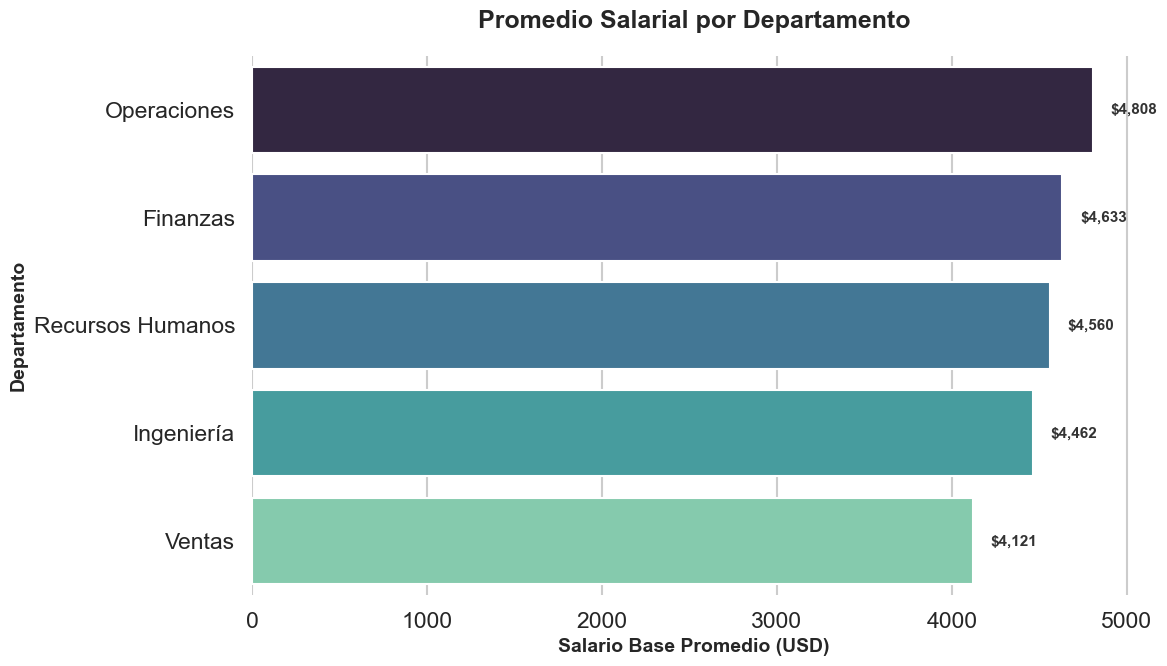

In [1]:
%pip install pymysql
# ==============================================================================
# Descripción: Módulo de extracción, análisis y visualización (BI) conectado a MySQL.
# Arquitectura: Lee directamente de la capa de presentación (Vista SQL)  
#               y optimiza el rendimiento.
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
import pandas as pd # La librería principal para análisis y manipulación de datos en Python.
from sqlalchemy import create_engine, exc # SQLAlchemy nos permite crear la conexión a la base de datos de forma segura. 'exc' captura errores de SQL.
import logging # Usado para registrar eventos, advertencias y errores (Trazabilidad). Fundamental en producción.
import matplotlib.pyplot as plt # Librería base para crear gráficos.
import seaborn as sns # Librería de visualización construida sobre matplotlib, ofrece gráficos más atractivos estadísticamente.

# ------------------------------------------------------------------------------
# 2. CONFIGURACIÓN DE TRAZABILIDAD
# ------------------------------------------------------------------------------
# Esto nos permite:
# - Saber la hora exacta en que ocurrió algo.
# - Clasificar mensajes (INFO, WARNING, ERROR, CRITICAL).
# - Enviar estos mensajes a un archivo de registro en un entorno de servidor real.
logging.basicConfig(
    level=logging.INFO, # Mostramos mensajes de nivel INFO en adelante.
    format='%(asctime)s - %(levelname)s - [HR_BI_ENGINE] - %(message)s' # Formato: Fecha - Nivel - [Etiqueta] - Mensaje
)
logger = logging.getLogger(__name__)

# ------------------------------------------------------------------------------
# 3. CLASE PRINCIPAL DEL MOTOR BI
# ------------------------------------------------------------------------------
# Usamos Programación Orientada a Objetos (POO) para mantener el código modular,
# organizado y fácil de mantener o expandir en el futuro.
class HRAnalyticsBI:
    
    # -- Método Constructor --
    # Se ejecuta automáticamente al crear un objeto (instancia) de la clase.
    # Recibe los parámetros de conexión. 
    # NOTA: En producción, NUNCA se ponen credenciales en texto plano;
    # se usan variables de entorno (ej: os.environ.get('DB_PASS')).
    def __init__(self, db_user='root', db_pass='', db_host='localhost', db_port='3306', db_name='hr_analytics'):
        """
        Inicializa el motor de análisis y la conexión a MySQL mediante SQLAlchemy.
        """
        # Se construye la 'Connection String' (Cadena de Conexión) en formato SQLAlchemy para MySQL
        self.db_uri = f"mysql+pymysql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}"
        
        # Inicializamos variables que usaremos después. 'None' y DataFrames vacíos como buena práctica.
        self.engine = None 
        self.df_analisis = pd.DataFrame() # Aquí guardaremos los datos extraídos
        self.kpi_deptos = pd.DataFrame()  # Aquí guardaremos los cálculos agrupados

    # -- Método para Conectar a la Base de Datos --
    def connect(self):
        """Establece la conexión a la base de datos con manejo de excepciones (try-except)."""
        try:
            # create_engine() prepara la conexión, pero no conecta inmediatamente
            self.engine = create_engine(self.db_uri)
            
            # Usamos el bloque 'with' para abrir la conexión, probarla y asegurarnos de que se cierre al terminar.
            with self.engine.connect():
                logger.info(f"Conexión exitosa a MySQL (Base de datos: {self.engine.url.database})")
                
        # Capturamos cualquier error específico de SQLAlchemy (ej. base de datos apagada, contraseña incorrecta)
        except exc.SQLAlchemyError as e:
            logger.critical(f"Error crítico al conectar a la base de datos: {e}")
            raise # Detenemos la ejecución del programa, no podemos continuar sin base de datos.

    # -- Método para Extraer los Datos --
    def fetch_data(self):
        """
        Extrae los datos desde la Vista SQL (`vw_analisis_salarial`).
        """
        logger.info("Extrayendo datos de la capa de presentación (vw_analisis_salarial)...")
        
        # OJO: Solo hacemos un 'SELECT *' porque la VISTA ya hizo todo el trabajo pesado 
        # (JOINs, Window Functions, filtros). Esto es una excelente práctica de rendimiento.
        query = "SELECT * FROM vw_analisis_salarial;"
        
        try:
            # pandas.read_sql() ejecuta la consulta usando el 'engine' y devuelve un DataFrame
            self.df_analisis = pd.read_sql(query, self.engine)
            logger.info(f"Datos extraídos correctamente. Total de registros analíticos: {len(self.df_analisis)}")
        except Exception as e:
            logger.error(f"Error al ejecutar la consulta analítica: {e}")
            raise

    # -- Método para Calcular los Indicadores Clave (KPIs) --
    def calculate_kpis(self):
        """Calcula las métricas de negocio solicitadas."""
        
        # Verificamos que el DataFrame no esté vacío antes de operar
        if self.df_analisis.empty:
            logger.warning("No hay datos para analizar en la vista. Deteniendo cálculos.")
            return

        logger.info("Calculando KPIs empresariales con Pandas...")

        # -- KPI 1: Promedio y Máximo Global --
        # Utilizamos funciones nativas de pandas (.mean() y .max()) sobre la columna 'salario_base'
        salario_promedio = self.df_analisis['salario_base'].mean()
        salario_maximo = self.df_analisis['salario_base'].max()
        
        # Para dar contexto, buscamos el nombre de la persona que tiene el salario máximo.
        # idxmax() nos da el 'índice' (la fila) donde está el valor máximo, y luego extraemos la columna 'nombre_completo'
        emp_max_salario = self.df_analisis.loc[self.df_analisis['salario_base'].idxmax(), 'nombre_completo']

        # -- KPI 2: Agrupación por Departamento --
        # Usamos .groupby() para agrupar por el nombre del departamento
        # y .agg() para aplicar múltiples cálculos matemáticos a distintas columnas al mismo tiempo.
        self.kpi_deptos = self.df_analisis.groupby('nombre_departamento').agg(
            total_empleados=('empleado_id', 'count'),    # Cuenta cuántos empleados hay
            salario_promedio=('salario_base', 'mean'),   # Promedio del salario base
            salario_maximo=('salario_base', 'max'),      # Máximo salario base
            gasto_total_nomina=('salario_neto', 'sum')   # Suma total de los salarios netos a pagar
        ).reset_index() # .reset_index() convierte 'nombre_departamento' de vuelta a una columna normal

        # Ordenamos los resultados de mayor a menor salario promedio
        self.kpi_deptos = self.kpi_deptos.sort_values(by='salario_promedio', ascending=False)

        # -- 3. Impresión del Reporte Ejecutivo en Consola --
        print("\n" + "="*70)
        print("📊 REPORTE EJECUTIVO - ANALÍTICA DE RECURSOS HUMANOS")
        print("="*70)
        # ':,.2f' formatea el número: coma para miles, punto decimal y 2 decimales.
        print(f"🔹 Salario Promedio Global: ${salario_promedio:,.2f}")
        print(f"🔹 Salario Máximo Global:   ${salario_maximo:,.2f} (Empleado: {emp_max_salario})")
        print("-" * 70)
        print("🔹 MÉTRICAS DETALLADAS POR DEPARTAMENTO:")
        
        # Creamos una función rápida (lambda) para formatear los números de las columnas como moneda
        formato_moneda = lambda x: f"${x:,.2f}"
        
        # Convertimos el DataFrame agrupado a texto (String) aplicando el formato de moneda a las columnas pertinentes
        reporte_str = self.kpi_deptos.to_string(
            index=False, # Ocultamos los números de fila (0, 1, 2...)
            formatters={
                'salario_promedio': formato_moneda,
                'salario_maximo': formato_moneda,
                'gasto_total_nomina': formato_moneda
            }
        )
        print(reporte_str) # Imprimimos la tabla formateada
        print("="*70 + "\n")

    # -- Método para Crear Gráficos (Visualización) --
    def visualize_data(self):
        """Genera un dashboard visual con calidad para presentación a directivos."""
        if self.kpi_deptos.empty:
            return

        logger.info("Renderizando visualizaciones con Seaborn...")
        
        # Definimos el estilo base del gráfico (cuadrícula blanca, texto grande 'talk')
        sns.set_theme(style="whitegrid", context="talk")
        
        # Creamos la figura y los ejes definiendo su tamaño (12 de ancho x 7 de alto)
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Usamos Seaborn para crear un gráfico de barras horizontales (sns.barplot)
        barplot = sns.barplot(
            x='salario_promedio',       # Eje X: El valor numérico
            y='nombre_departamento',    # Eje Y: Las categorías
            data=self.kpi_deptos,       # Origen de datos: Nuestro DataFrame agrupado
            hue='nombre_departamento',  # Colorea cada barra distinto según el departamento
            palette='mako',             # Paleta de colores profesional predefinida
            legend=False,               # Ocultamos la leyenda porque los nombres ya están en el eje Y
            ax=ax                       # Le indicamos que dibuje en los ejes creados arriba
        )
        
        # Bucle para añadir los números (etiquetas) al lado de cada barra
        for p in barplot.patches:
            width = p.get_width() # Obtenemos el valor de la barra (el salario promedio)
            
            # plt.text() dibuja texto en coordenadas específicas del gráfico
            plt.text(width + 100, # Posición X: al final de la barra + un pequeño margen (100)
                     p.get_y() + p.get_height() / 2, # Posición Y: A la mitad de la altura de la barra
                     f'${width:,.0f}', # El texto a mostrar (formateado sin decimales)
                     ha='left', va='center', # Alineación horizontal (izquierda) y vertical (centro)
                     fontsize=11, fontweight='bold', color='#333333')

        # -- Formateo y limpieza visual del gráfico --
        ax.set_title('Promedio Salarial por Departamento', fontsize=18, fontweight='bold', pad=20)
        ax.set_xlabel('Salario Base Promedio (USD)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Departamento', fontsize=14, fontweight='bold')
        
        # sns.despine() quita las líneas del recuadro superior y derecho del gráfico para un diseño más moderno y limpio.
        sns.despine(left=True, bottom=True)
        
        # Ajusta automáticamente los márgenes para que no se corte ningún texto
        plt.tight_layout()
        
        # Muestra la ventana con el gráfico terminado
        plt.show()

# ------------------------------------------------------------------------------
# 4. PUNTO DE ENTRADA (MAIN)
# ------------------------------------------------------------------------------
# Esta condición asegura que el código solo se ejecute si corremos el archivo directamente 
# (ej. 'python hr_bi_analytics.py') y NO si lo importamos desde otro archivo.
if __name__ == "__main__":
    
    # Creamos un objeto de nuestra clase configurando la conexión a Laragon/MySQL
    bi_engine = HRAnalyticsBI(
        db_user='root', 
        db_pass='',        # En Laragon suele venir sin contraseña por defecto
        db_host='localhost', 
        db_port='3306', 
        db_name='hr_analytics'
    )
    
    # Ejecutamos los métodos en orden lógico envueltos en un try-except para atrapar 
    # errores no previstos durante todo el proceso.
    try:
        bi_engine.connect()          # 1. Conectamos
        bi_engine.fetch_data()       # 2. Extraemos datos
        bi_engine.calculate_kpis()   # 3. Hacemos cálculos e imprimimos el reporte
        bi_engine.visualize_data()   # 4. Dibujamos el gráfico
        
    except Exception as e:
        # Si algo falla en los 4 pasos anteriores, el script no "explota", sino que registra este error
        # e incluye el detalle de la variable 'e' que causó el problema.
        logger.critical(f"El proceso de Business Intelligence ha fallado. Revisa los logs. Detalle: {e}")

## Conclusión

# Modelo Dimensional (Nicole)

# Ejercicio Propuesto

Construir un modelo dimensional para Recursos Humanos.

## Requerimientos

1. Crear:
   - dimensión empleados,
   - dimensión departamentos,
   - dimensión tiempo,
   - fact salarios.

2. Generar:
   - mínimo 100 registros.

3. Analizar:
   - salario promedio,
   - salario máximo,
   - salarios por departamento,
   - salarios por mes.

4. Mostrar:
   - Top 5 empleados con mayor salario.

## Base de datos

## Registros

## Resultados

## Visualización en python

## Conclusión

# Diseño de tablas fact y dimención (Eunice)

## Ejercicio Propuesto

Construir un modelo dimensional para Recursos Humanos.

### Requerimientos

1. Crear:
   - dimensión empleados,
   - dimensión departamentos,
   - dimensión tiempo,
   - fact salarios.

2. Utilizar:
   - surrogate keys.

3. Generar:
   - mínimo 300 registros.

4. Analizar:
   - salario promedio,
   - salario máximo,
   - salarios por departamento,
   - salarios por mes.

5. Mostrar:
   - Top 10 empleados con mayor salario.

## Base de datos

## Registros

## Resultados

## Visualización en python

## Conclusión